Reading: /InternetSales.csv


/tmp/ipython-input-3899081114.py:22: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, encoding="latin-1")
/tmp/ipython-input-3899081114.py:58: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(df[date_like[0]], errors="coerce", infer_datetime_format=True)



Detected columns:
  Sales column -> SalesAmount
  Year source  -> OrderDate

Yearly totals (preview):
   Year   SalesAmount
0  2010  4.342104e+04
1  2011  7.075526e+06
2  2012  5.842485e+06
3  2013  1.635155e+07
4  2014  4.569472e+04

Saved PDF to: /content/yearly_internet_sales.pdf
Saved aggregated data to: /content/yearly_internet_sales.csv


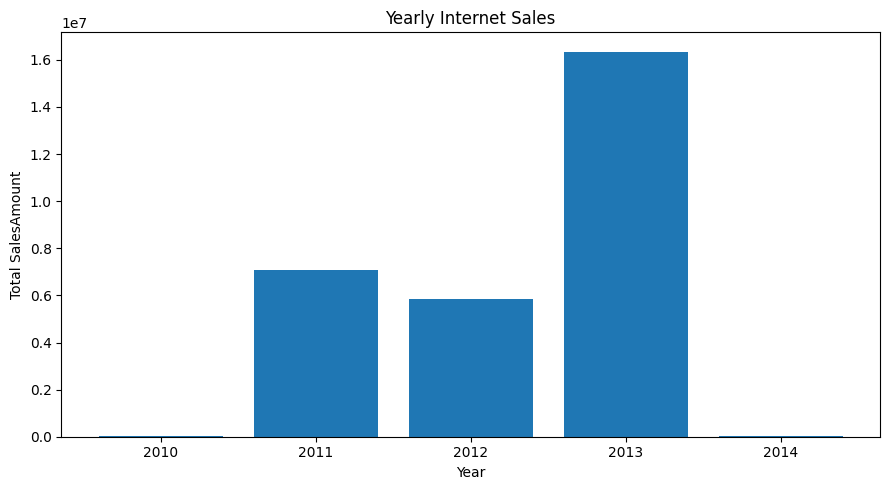

In [9]:
# === Week 7: InternetSales yearly bar chart + save as PDF ===
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# 1) Locate the CSV (adjust NAME if you renamed it)
CANDIDATE_PATHS = [
    "/InternetSales.csv",          # << added based on your message
    "InternetSales.csv",
    "/content/InternetSales.csv",
    "/mnt/data/InternetSales.csv"
]
csv_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(
        "Couldn't find InternetSales.csv. Put it in the Colab working directory "
        "or update CANDIDATE_PATHS to the correct location."
    )

print(f"Reading: {csv_path}")
df = pd.read_csv(csv_path, encoding="latin-1")



# 2) Try to detect the date/year column and the sales/amount column
#    (Change these lists if your headers are different.)
date_like = [c for c in df.columns if str(c).lower() in
             ["date","orderdate","invoice date","invoice_date","order date","order_date","transactiondate","transaction_date"]]
year_like = [c for c in df.columns if str(c).lower() in ["year","fiscal_year","calendar_year"]]
amount_like = [c for c in df.columns if str(c).lower() in
               ["sales","salesamount","sales_amount","amount","revenue","total","total_amount","net_sales"]]

if not amount_like:
    # As a fallback, guess the first numeric column that looks like money
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    if numeric_cols:
        amount_like = [numeric_cols[0]]
    else:
        raise ValueError("Couldn't find a numeric sales/amount column. Please rename your sales column to one of: "
                         "'Sales', 'SalesAmount', 'Amount', 'Revenue', 'Total'.")

sales_col = amount_like[0]

# Build a Year column
if year_like:
    year_col = year_like[0]
    df["Year"] = pd.to_numeric(df[year_col], errors="coerce")
else:
    if not date_like:
        # Try any column containing 'date' in its name
        date_like = [c for c in df.columns if "date" in str(c).lower()]
    if not date_like:
        # last resort: try to parse the first column as a date
        date_like = [df.columns[0]]

    # parse to datetime -> Year
    parsed = pd.to_datetime(df[date_like[0]], errors="coerce", infer_datetime_format=True)
    if parsed.isna().all():
        raise ValueError(
            "Couldn't parse a date column. Please ensure you have a 'Date'/'OrderDate' column "
            "or a 'Year' column."
        )
    df["Year"] = parsed.dt.year

# 3) Aggregate yearly sales
yearly = (
    df.dropna(subset=["Year"])
      .groupby("Year", as_index=False)[sales_col].sum()
      .sort_values("Year")
)
print("\nDetected columns:")
print(f"  Sales column -> {sales_col}")
print(f"  Year source  -> {'Year column' if year_like else date_like[0]}")
print("\nYearly totals (preview):")
print(yearly.head(10))

# 4) Plot bar chart
plt.figure(figsize=(9,5))
plt.bar(yearly["Year"].astype(int).astype(str), yearly[sales_col])
plt.title("Yearly Internet Sales")
plt.xlabel("Year")
plt.ylabel(f"Total {sales_col}")
plt.xticks(rotation=0)
plt.tight_layout()

# 5) Save active figure to PDF
out_pdf = "/content/yearly_internet_sales.pdf" if os.path.exists("/content") else "yearly_internet_sales.pdf"
plt.savefig(out_pdf, format="pdf")
print(f"\nSaved PDF to: {out_pdf}")

# (Optional) Also save the aggregated data for your repo / Canvas upload
out_csv = "/content/yearly_internet_sales.csv" if os.path.exists("/content") else "yearly_internet_sales.csv"
yearly.to_csv(out_csv, index=False)
print(f"Saved aggregated data to: {out_csv}")

# Show the chart in Colab
plt.show()


In [10]:
from google.colab import files
files.download('/content/yearly_internet_sales.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>